# <h1 style="color: yellow;">Genetic Algorithm Model (second alternative model)</h1>

In [ ]:
#Ga - Genetic Algorithm

#Can we improve the model by automatically finding the best subset of variables?

#However, it is important to note that to use this model, we need to combine it with a linear regression model, since the Genetic Algorithm (GA) model will return the best combination of variables.
#This way, we can evaluate whether the GA is truly able to find a configuration that improves upon our baseline.

## Libraries

In [14]:
#Call libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Functions

In [40]:
#Function that will select which factors allow the model to generalize better to data not used during training
def fitness_function(solution):
    '''
        The lower the RMSE, the better the solution.
        Using the cross-validation method, we will obtain a mean squared error for 5-fold cross-validation.
    '''

    selected_features = solution == 1

    #Avoid solutions with no selected features
    if selected_features.sum() == 0:
        return float("inf")

    X_selected = X_train_processed[:, selected_features]

    model = LinearRegression()

    scores = cross_val_score(
        model,
        X_selected,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    #Now, the GA seeks a solution that performs well outside the training sample, rather than simply a solution that memorizes X_train.
    return -scores.mean()

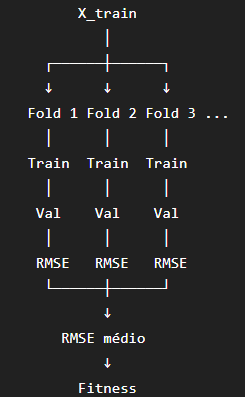

In [ ]:
#Selection
#Function to select the best individual that will win the comparison contest
def tournament_selection(population, fitness_scores):

    '''
        We pick two individuals at random and let the best one win.
    '''
    
    idx1, idx2 = np.random.choice(
        len(population),
        size=2,
        replace=False
    )

    if fitness_scores[idx1] < fitness_scores[idx2]:
        return population[idx1]
    else:
        return population[idx2]

In [ ]:
#Crossover
#Function to concatenate the algorithms of two individuals at a random crossover point, generating an offspring with the genetic characteristics of both.
def crossover(parent1, parent2):
    '''
        Function to concatenate the algorithms of two individuals at a random crossover point, 
        generating an offspring with the genetic characteristics of both.
    '''

    #The selection will be made by a draw.
    point = np.random.randint(
        1,
        len(parent1)
    )

    child = np.concatenate([
        parent1[:point],
        parent2[point:]
    ])

    return child

In [43]:
#Mutation
#Function that randomly alters a child's genes based on a probability rate.
def mutation(child, mutation_rate):
    '''
        Function that randomly alters a child's genes based on a probability rate.
    '''
    for i in range(len(child)):

        if np.random.rand() < mutation_rate:
            child[i] = 1 - child[i]

    return child

## Training and tests variables import

In [16]:
#Import 80/20 model
import sys
sys.path.append("../")

from Variables.Training_test_variables_80_20 import (
    X,
    y,
    X_train,
    X_test,
    y_train,
    y_test
)

## One-Hot encoding

In [17]:
#Columns type identification
categorical_columns = X.select_dtypes(
    include=["object", "string"]
).columns.tolist() #-> 14

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist() #-> 6

#Create the categorical columns preprocessing (the combination of values will result in 34 new categorical columns)
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_columns
        )
    ],
    remainder="passthrough" #The numeric columns will pass directly
)
#Note:
#The `handle_unknown="ignore"` setting is important. Imagine a category appearing in `X_test` that didn't exist in `X_train`. The encoder won't break.

## Data transformation process (GA - initial step)

In [ ]:
#GA selecting the 40 features after preprocessing.

#Data transformation process
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

#Features definition
feature_names = preprocessor.get_feature_names_out()

#We have 40 features now
print(feature_names)
print(X_train_processed.shape)
print(X_test_processed.shape)

['categorical__Parental_Involvement_high'
 'categorical__Parental_Involvement_low'
 'categorical__Parental_Involvement_medium'
 'categorical__Access_to_Resources_high'
 'categorical__Access_to_Resources_low'
 'categorical__Access_to_Resources_medium'
 'categorical__Extracurricular_Activities_no'
 'categorical__Extracurricular_Activities_yes'
 'categorical__Motivation_Level_high' 'categorical__Motivation_Level_low'
 'categorical__Motivation_Level_medium' 'categorical__Internet_Access_no'
 'categorical__Internet_Access_yes' 'categorical__Family_Income_high'
 'categorical__Family_Income_low' 'categorical__Family_Income_medium'
 'categorical__Teacher_Quality_high' 'categorical__Teacher_Quality_low'
 'categorical__Teacher_Quality_medium' 'categorical__School_Type_private'
 'categorical__School_Type_public' 'categorical__Peer_Influence_negative'
 'categorical__Peer_Influence_neutral'
 'categorical__Peer_Influence_positive'
 'categorical__Learning_Disabilities_no'
 'categorical__Learning_Disa

## Manual determination of the best solution (GA - addtional step)

In [24]:
#First, we need to create an initial population.
n_features = X_train_processed.shape[1]
population_size = 600 #Just an example based on a fraction of the original quantity (~6,000).
#The population size is directly related to the computational cost.

population = np.random.randint(
    0,
    2,
    size=(population_size, n_features)
)

print(population.shape)

(600, 40)


In [25]:
#Then, we evaluate each individual using our fitness_function.
fitness_scores = []

for solution in population:
    fitness = fitness_function(solution)
    fitness_scores.append(fitness)

print(fitness_scores)

[np.float64(2.8301579862476407), np.float64(3.2196813348339797), np.float64(3.6911276966593354), np.float64(2.8232161859990237), np.float64(2.8538362128556125), np.float64(3.263026801933367), np.float64(3.690503278167281), np.float64(3.1810158000877573), np.float64(3.1774879633533515), np.float64(3.2140778046247007), np.float64(3.707336643820608), np.float64(2.8978954169599236), np.float64(2.9021990164125375), np.float64(2.841621394710849), np.float64(2.3378257104647533), np.float64(3.263815409662449), np.float64(3.103055147176988), np.float64(3.6234291497680062), np.float64(2.202207895506781), np.float64(3.562475066476291), np.float64(2.889207068658001), np.float64(3.2356976816146967), np.float64(3.632865409776131), np.float64(2.85141709045659), np.float64(2.8473127709755457), np.float64(3.607909433643484), np.float64(2.288778005959539), np.float64(3.6751629252572267), np.float64(3.1541996673176644), np.float64(3.688806267475569), np.float64(2.810404074638709), np.float64(3.2412291494

In [ ]:
#Since a lower RMSE is better, we can find the index of the best one.
best_index = np.argmin(fitness_scores) #returns the index (the position) of the smallest value in a NumPy array
print(best_index)

#Finally the best solution variables combination
best_solution = population[best_index]
print(best_solution)

374
[0 1 1 0 1 1 1 0 0 1 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 1 1
 1 1 1]


In [ ]:
#Finally the best solution variables combination (names)
selected_features = feature_names[best_solution == 1]
print(selected_features)

#Attention:
   #This is still just the first generation.
   #We identified the best individual from the initial population, but we haven't yet found the truly "genetic" part.

['categorical__Parental_Involvement_low'
 'categorical__Parental_Involvement_medium'
 'categorical__Access_to_Resources_low'
 'categorical__Access_to_Resources_medium'
 'categorical__Extracurricular_Activities_no'
 'categorical__Motivation_Level_low'
 'categorical__Motivation_Level_medium' 'categorical__Family_Income_high'
 'categorical__Family_Income_medium' 'categorical__Teacher_Quality_high'
 'categorical__Teacher_Quality_low' 'categorical__Teacher_Quality_medium'
 'categorical__School_Type_public' 'categorical__Peer_Influence_positive'
 'categorical__Learning_Disabilities_no'
 'categorical__Learning_Disabilities_yes'
 'categorical__Parental_Education_Level_high school'
 'categorical__Parental_Education_Level_postgraduate'
 'categorical__Distance_from_Home_far'
 'categorical__Distance_from_Home_near' 'categorical__Gender_female'
 'remainder__Hours_Studied' 'remainder__Attendance'
 'remainder__Sleep_Hours' 'remainder__Previous_Scores'
 'remainder__Tutoring_Sessions' 'remainder__Physi

In [ ]:
X_train_ga = X_train_processed[:, best_solution == 1]
X_test_ga = X_test_processed[:, best_solution == 1]

model_ga = LinearRegression()

model_ga.fit(X_train_ga, y_train)

y_pred_ga = model_ga.predict(X_test_ga)

## Construction of the complete genetic algorithm model

### Genetic Algorithm Parameters

In [45]:
#Initial parameters
population_size = 600
n_generations = 30
mutation_rate = 0.05

#population_size: 600 solutions per generation -> x 5 folds in fitness function = 3000 training runs
#n_generations: the algorithm will evolve for 30 generations
#mutation_rate: 5% chance of each gene undergoing mutation

### Create the initial population

In [46]:
n_features = X_train_processed.shape[1]

population = np.random.randint(
    0,
    2,
    size=(population_size, n_features)
)
display(population)

array([[0, 0, 0, ..., 1, 0, 1],
       [0, 1, 0, ..., 1, 1, 1],
       [1, 0, 1, ..., 1, 0, 0],
       ...,
       [0, 0, 1, ..., 1, 1, 0],
       [1, 1, 1, ..., 0, 1, 1],
       [0, 0, 1, ..., 0, 0, 1]], shape=(600, 40))

### Assess the population


In [47]:
fitness_scores = []

for solution in population:
    fitness = fitness_function(solution)
    fitness_scores.append(fitness)
    
print(fitness_scores)
#Attetion -> The lower the RMSE, the better the individual.

[np.float64(2.323704987278845), np.float64(2.86678915729065), np.float64(3.2162553090296724), np.float64(2.228639424878745), np.float64(2.2690538982124435), np.float64(2.8017795974268167), np.float64(3.223083689878498), np.float64(3.0905275296733983), np.float64(3.688833367081185), np.float64(3.7885325126617198), np.float64(2.8979290974225225), np.float64(2.9904306444526263), np.float64(2.876272459707495), np.float64(3.6487371688633714), np.float64(3.756271485038346), np.float64(2.3755500065509674), np.float64(2.4117678619405956), np.float64(2.882037714639054), np.float64(2.81135570732361), np.float64(2.909779878923838), np.float64(3.6455580853930067), np.float64(3.255504796671141), np.float64(3.2350938051825198), np.float64(3.628965496090604), np.float64(2.195610215366674), np.float64(3.2403327584429853), np.float64(3.13467118771987), np.float64(3.6028103496864192), np.float64(3.7572362791024565), np.float64(2.2398350352874794), np.float64(3.719749378391075), np.float64(2.925409849480

### Finding the best individual (student)

In [49]:
best_index = np.argmin(fitness_scores)

best_solution = population[best_index]
best_fitness = fitness_scores[best_index]

print("Best fitness:", best_fitness)
print("Selected features:", best_solution.sum())

Best fitness: 2.0635402514366232
Selected features: 24


In [ ]:
#This means that this solution used 24 of the 40 features.

### Genetic assimilation - Selection x Crossover x Mutation

In [50]:
#The best samples will generate a strong performance history based on the defined selection, crossover, and mutation functions 
#and the initial parameters established as a standard example.
new_population = []

for _ in range(population_size):

    parent1 = tournament_selection(
        population,
        fitness_scores
    )

    parent2 = tournament_selection(
        population,
        fitness_scores
    )

    child = crossover(parent1, parent2)

    child = mutation(
        child,
        mutation_rate
    )

    new_population.append(child)

population = np.array(new_population)

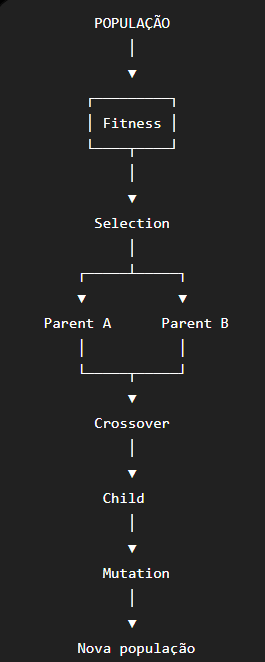

### Genetic loop - Compiling the entire algorithm in a loop

In [51]:
best_solution = None
best_fitness = float("inf")

for generation in range(n_generations):

    fitness_scores = [
        fitness_function(solution)
        for solution in population
    ]

    generation_best_index = np.argmin(
        fitness_scores
    )

    generation_best_fitness = fitness_scores[
        generation_best_index
    ]

    if generation_best_fitness < best_fitness:

        best_fitness = generation_best_fitness

        best_solution = population[
            generation_best_index
        ].copy()

    print(
        f"Generation {generation + 1}: "
        f"Best RMSE = {generation_best_fitness:.4f}"
    )

    new_population = []

    for _ in range(population_size):

        parent1 = tournament_selection(
            population,
            fitness_scores
        )

        parent2 = tournament_selection(
            population,
            fitness_scores
        )

        child = crossover(parent1, parent2)

        child = mutation(
            child,
            mutation_rate
        )

        new_population.append(child)

    population = np.array(new_population)

Generation 1: Best RMSE = 2.0627
Generation 2: Best RMSE = 2.0582
Generation 3: Best RMSE = 2.0341
Generation 4: Best RMSE = 2.0442
Generation 5: Best RMSE = 2.0341
Generation 6: Best RMSE = 2.0341
Generation 7: Best RMSE = 2.0343
Generation 8: Best RMSE = 2.0339
Generation 9: Best RMSE = 2.0334
Generation 10: Best RMSE = 2.0336
Generation 11: Best RMSE = 2.0334
Generation 12: Best RMSE = 2.0334
Generation 13: Best RMSE = 2.0332
Generation 14: Best RMSE = 2.0334
Generation 15: Best RMSE = 2.0332
Generation 16: Best RMSE = 2.0332
Generation 17: Best RMSE = 2.0332
Generation 18: Best RMSE = 2.0332
Generation 19: Best RMSE = 2.0334
Generation 20: Best RMSE = 2.0332
Generation 21: Best RMSE = 2.0334
Generation 22: Best RMSE = 2.0332
Generation 23: Best RMSE = 2.0332
Generation 24: Best RMSE = 2.0334
Generation 25: Best RMSE = 2.0334
Generation 26: Best RMSE = 2.0334
Generation 27: Best RMSE = 2.0334
Generation 28: Best RMSE = 2.0334
Generation 29: Best RMSE = 2.0332
Generation 30: Best RMS

In [ ]:
#Note:
#It can be observed that, starting from the 11th generation, the individuals have already reached the optimal configuration, 
#rendering the subsequent ones redundant.

### Best generation solution

In [52]:
#Finally
best_solution
best_fitness

np.float64(2.0332061041472316)

In [60]:
#Best features selected for incorporation into a regression model
selected_features = feature_names[
    best_solution == 1
]

print(selected_features)
print("Number of features:", best_solution.sum())

['categorical__Parental_Involvement_high'
 'categorical__Parental_Involvement_medium'
 'categorical__Access_to_Resources_high'
 'categorical__Access_to_Resources_low'
 'categorical__Access_to_Resources_medium'
 'categorical__Extracurricular_Activities_no'
 'categorical__Motivation_Level_high' 'categorical__Motivation_Level_low'
 'categorical__Internet_Access_yes' 'categorical__Family_Income_high'
 'categorical__Family_Income_low' 'categorical__Family_Income_medium'
 'categorical__Teacher_Quality_high' 'categorical__Teacher_Quality_low'
 'categorical__Teacher_Quality_medium'
 'categorical__Peer_Influence_negative'
 'categorical__Peer_Influence_neutral'
 'categorical__Peer_Influence_positive'
 'categorical__Learning_Disabilities_yes'
 'categorical__Parental_Education_Level_college'
 'categorical__Parental_Education_Level_high school'
 'categorical__Distance_from_Home_moderate'
 'categorical__Distance_from_Home_near' 'remainder__Hours_Studied'
 'remainder__Attendance' 'remainder__Previous

## Create the linear regression model using the best features selected by the genetic algorithm model

In [ ]:
#Select the features chosen by the Genetic Algorithm
selected_features = best_solution == 1

X_train_ga = X_train_processed[:, selected_features]
X_test_ga = X_test_processed[:, selected_features]

#Model training
model_ga = LinearRegression()

model_ga.fit(
    X_train_ga,
    y_train
)

y_pred_ga = model_ga.predict(
    X_test_ga
)

## Using loss functions to validate the model (metrics comparison)

In [68]:
#Mean absolute error
mae = mean_absolute_error(y_test, y_pred_ga)

#Mean squared error
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ga))

#r2 error
r2 = r2_score(y_test, y_pred_ga)

#r2 error adjusted
n = len(y_test)
p = X_test_ga.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

#Results from model
print(f"MAE:  {mae:.5f}")
print(f"RMSE: {rmse:.5f}")
print(f"R²:   {r2:.5f}")
print(f"Adjusted R²: {adjusted_r2:.5f}")

MAE:  0.47701
RMSE: 2.03898
R²:   0.73441
Adjusted R²: 0.72845


In [ ]:
#Features comparison
print("Baseline features:", X_train_processed.shape[1])
print("GA features:", X_train_ga.shape[1])

Baseline features: 40
GA features: 28


In [ ]:
#Notes:
   #The Genetic Algorithm reduced the number of features from 40 to 28 (30% reduction)
   #while maintaining similar predictive performance compared to the baseline Linear Regression model.
   #This suggests that some features had limited impact on the model's predictive performance.

In [71]:
#The selected features
print("\nSelected features:")
for feature in selected_features:
    print(feature)


Selected features:
categorical__Parental_Involvement_high
categorical__Parental_Involvement_medium
categorical__Access_to_Resources_high
categorical__Access_to_Resources_low
categorical__Access_to_Resources_medium
categorical__Extracurricular_Activities_no
categorical__Motivation_Level_high
categorical__Motivation_Level_low
categorical__Internet_Access_yes
categorical__Family_Income_high
categorical__Family_Income_low
categorical__Family_Income_medium
categorical__Teacher_Quality_high
categorical__Teacher_Quality_low
categorical__Teacher_Quality_medium
categorical__Peer_Influence_negative
categorical__Peer_Influence_neutral
categorical__Peer_Influence_positive
categorical__Learning_Disabilities_yes
categorical__Parental_Education_Level_college
categorical__Parental_Education_Level_high school
categorical__Distance_from_Home_moderate
categorical__Distance_from_Home_near
remainder__Hours_Studied
remainder__Attendance
remainder__Previous_Scores
remainder__Tutoring_Sessions
remainder__Phy